In [2]:
import numpy as np 
import matplotlib.pyplot as plt

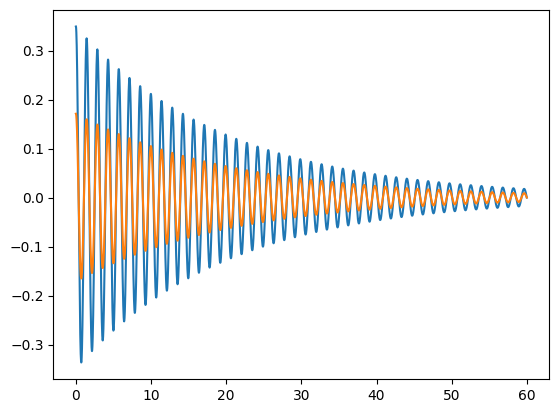

In [ ]:


# Parameters
length = 0.5
g = 9.80665
theta0 = np.deg2rad(20)
omega0 = 0.0
dt = 0.01
tmax = 60

# Initialize
theta = theta0
omega = omega0
origin = np.array([0.0, 0.0])

# Arrays to store results
t = np.arange(0, tmax, dt)

def acc(t,theta,omega):
    beta = -0.1
    return - (g / length)*np.sin(theta) + beta*omega

def verlet(t, func, r0, v0):
    r = np.zeros_like(t)
    v = np.zeros_like(t)
    a = np.zeros_like(t)
    dt = t[1] - t[0]

    r[0] = r0
    v[0] = v0
    a[0] = func(t[0], r[0], v[0])

    for i in range(len(t) - 1):
        r[i+1] = r[i] + v[i] * dt + 0.5 * a[i] * dt**2
        a[i+1] = func(t[i+1], r[i+1], v[i])
        v[i+1] = v[i] + 0.5 * (a[i] + a[i+1]) * dt
    return r, v, a

theta, omega, omegadot = verlet(t,acc,theta0,omega0)
# Convert to Cartesian coordinates
x = length * np.sin(theta)
y = -length * np.cos(theta)
plt.plot(t,theta)
plt.plot(t,x)



(0.0, 1.5)

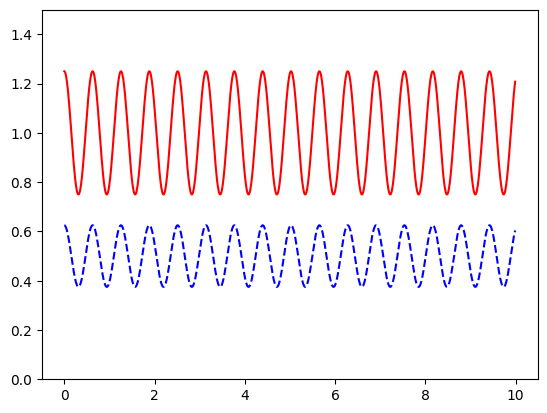

In [21]:
## simulate a spring!
p0 = 1
p1 = p0/2

p00 = 1.25 
p10 = p00/2

x0 = p00 - p0 
x1 = p10 - p1 

def acc(t,r,v):
    k = 100
    return -k*r 
 
t = np.arange(0,10,0.01)
x0t, v0t, a0t = verlet(t,acc,x0,0)
x1t, v1t, a1t = verlet(t,acc,x1,0)
x0t += p0 
x1t += p1
plt.plot(t,x0t,'r')
plt.plot(t,x1t,'b--')
plt.ylim(0,1.5)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def science_plot(fontsize=9, scistyle=True, show_latex=True):
    # Default settings (applied to both 2D and 3D)
    if scistyle:
        import scienceplots
        plt.style.use(['science','grid','notebook'])
    if show_latex:
        plt.rcParams.update({
            # Latex Use
            'text.usetex'     : True,        # Use LaTeX for text rendering
            'font.family'     : 'serif',     # Set font family to serif
        })

    plt.rcParams.update({
        # Fontsizes
        'font.size'       : fontsize,    # General font size
        'axes.titlesize'  : fontsize,    # Font size of the axes title
        'axes.labelsize'  : fontsize,    # Font size of the axes labels
        'xtick.labelsize' : fontsize,    # Font size of the x-axis tick labels
        'ytick.labelsize' : fontsize,    # Font size of the y-axis tick labels
        'legend.fontsize' : fontsize,    # Font size of the legend
        'figure.titlesize': fontsize,    # Font size of the figure title

        # Legend
        'legend.fancybox' : False,       # Disable the fancy box for legend
        'legend.edgecolor': 'k',         # Set legend border color to black
    })
science_plot(fontsize=9)

\textbf{Coupled Damped Pendula — in phase}


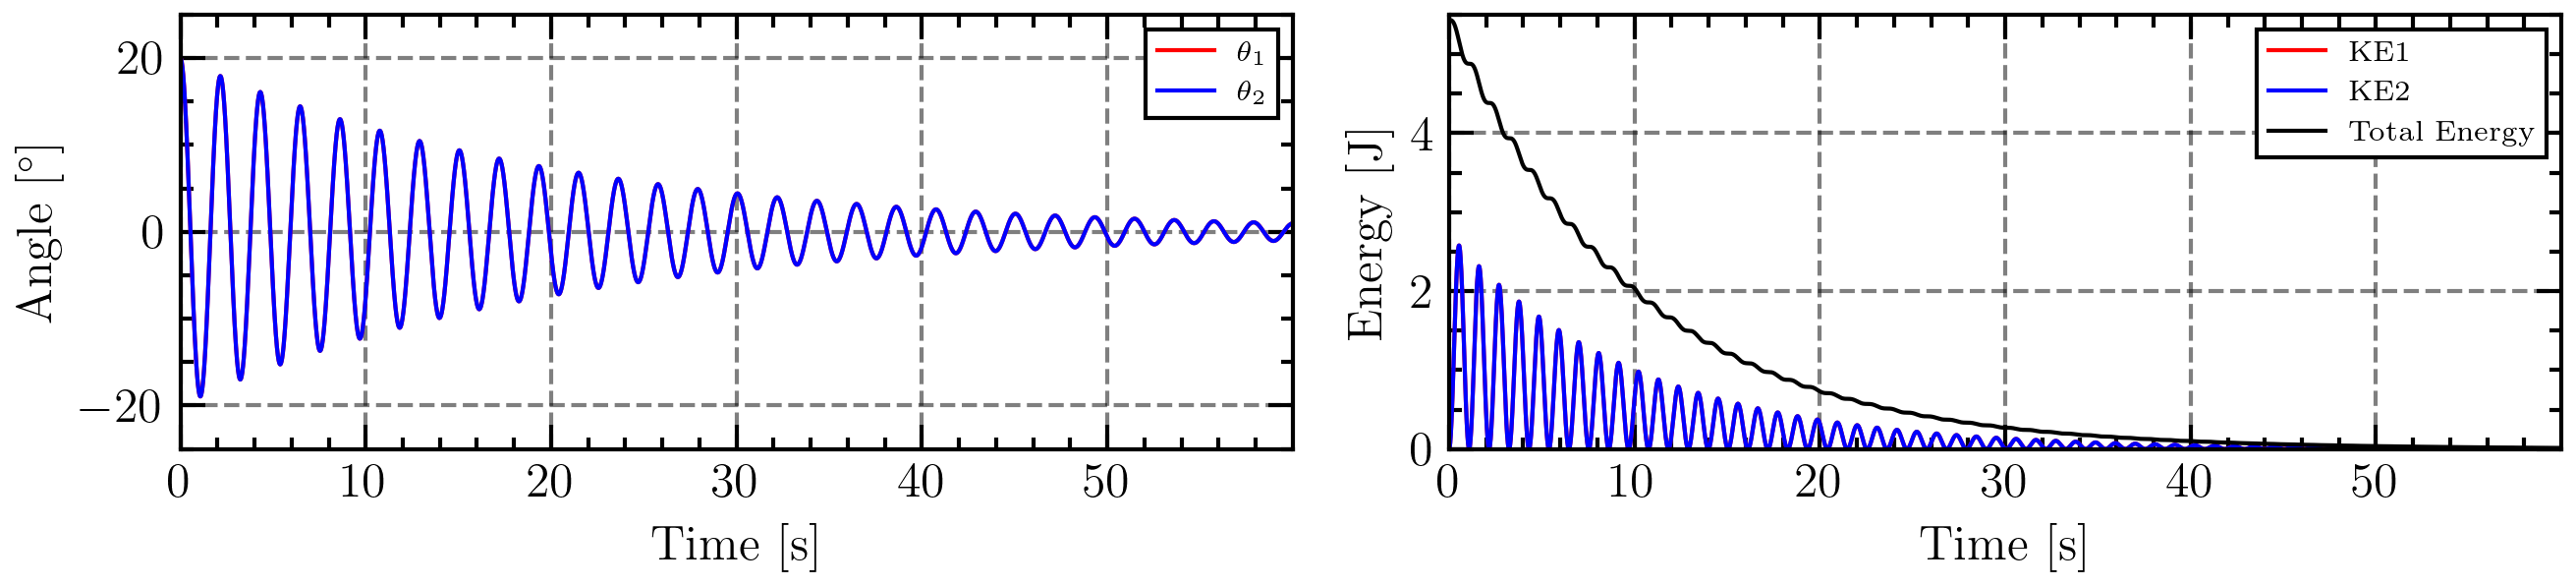

\textbf{Coupled Damped Pendula — out of phase}


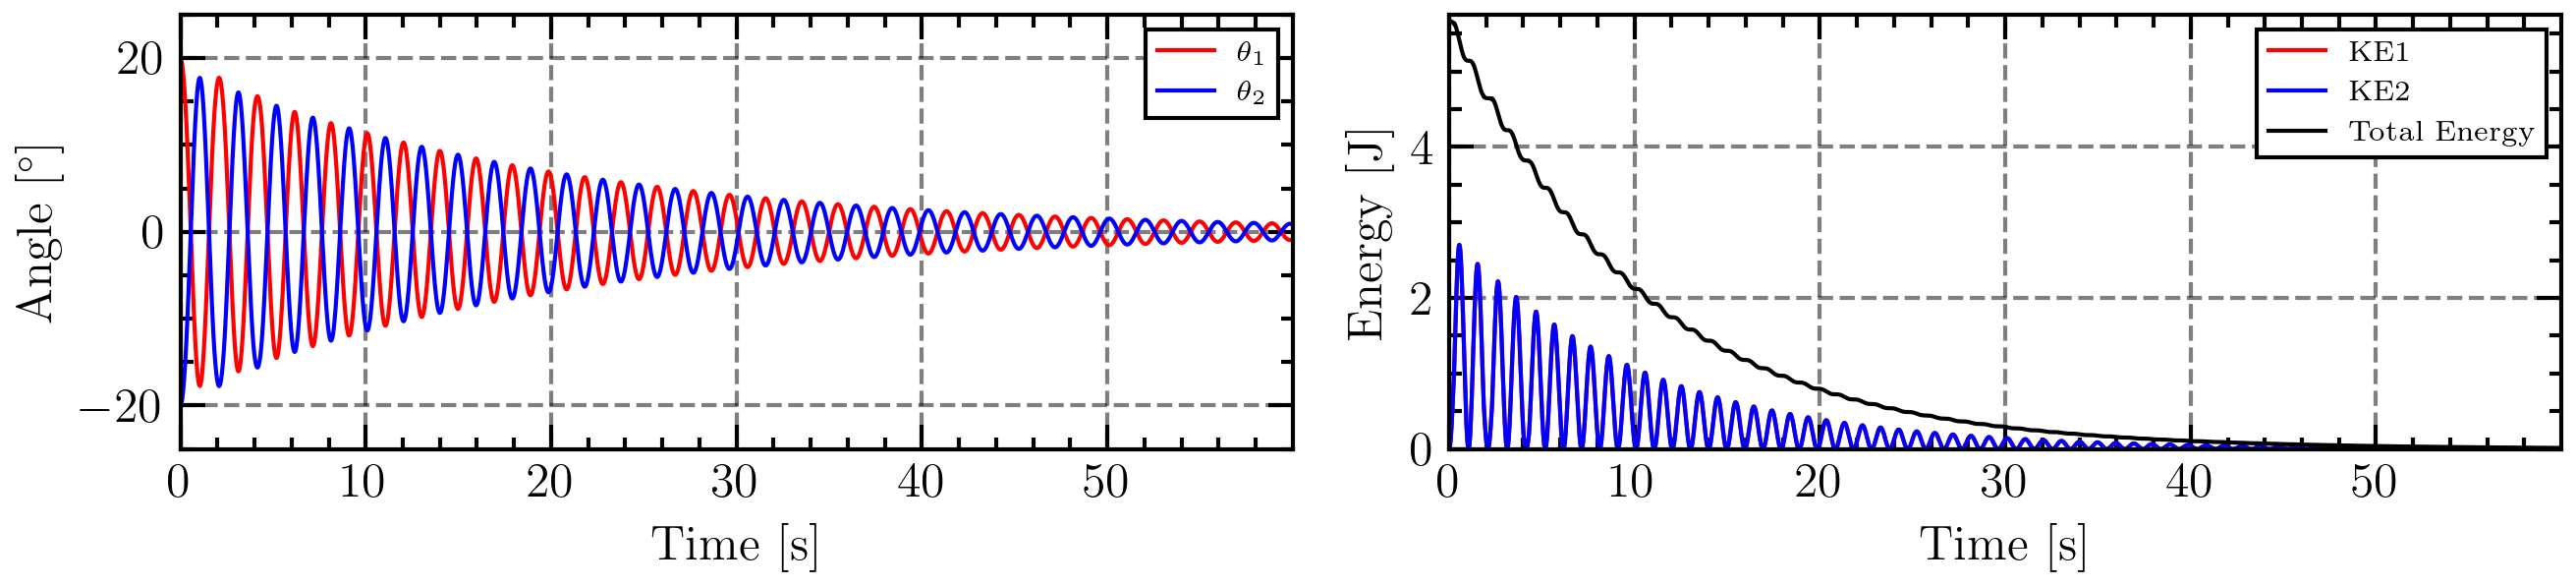

\textbf{Coupled Damped Pendula — one stationary}


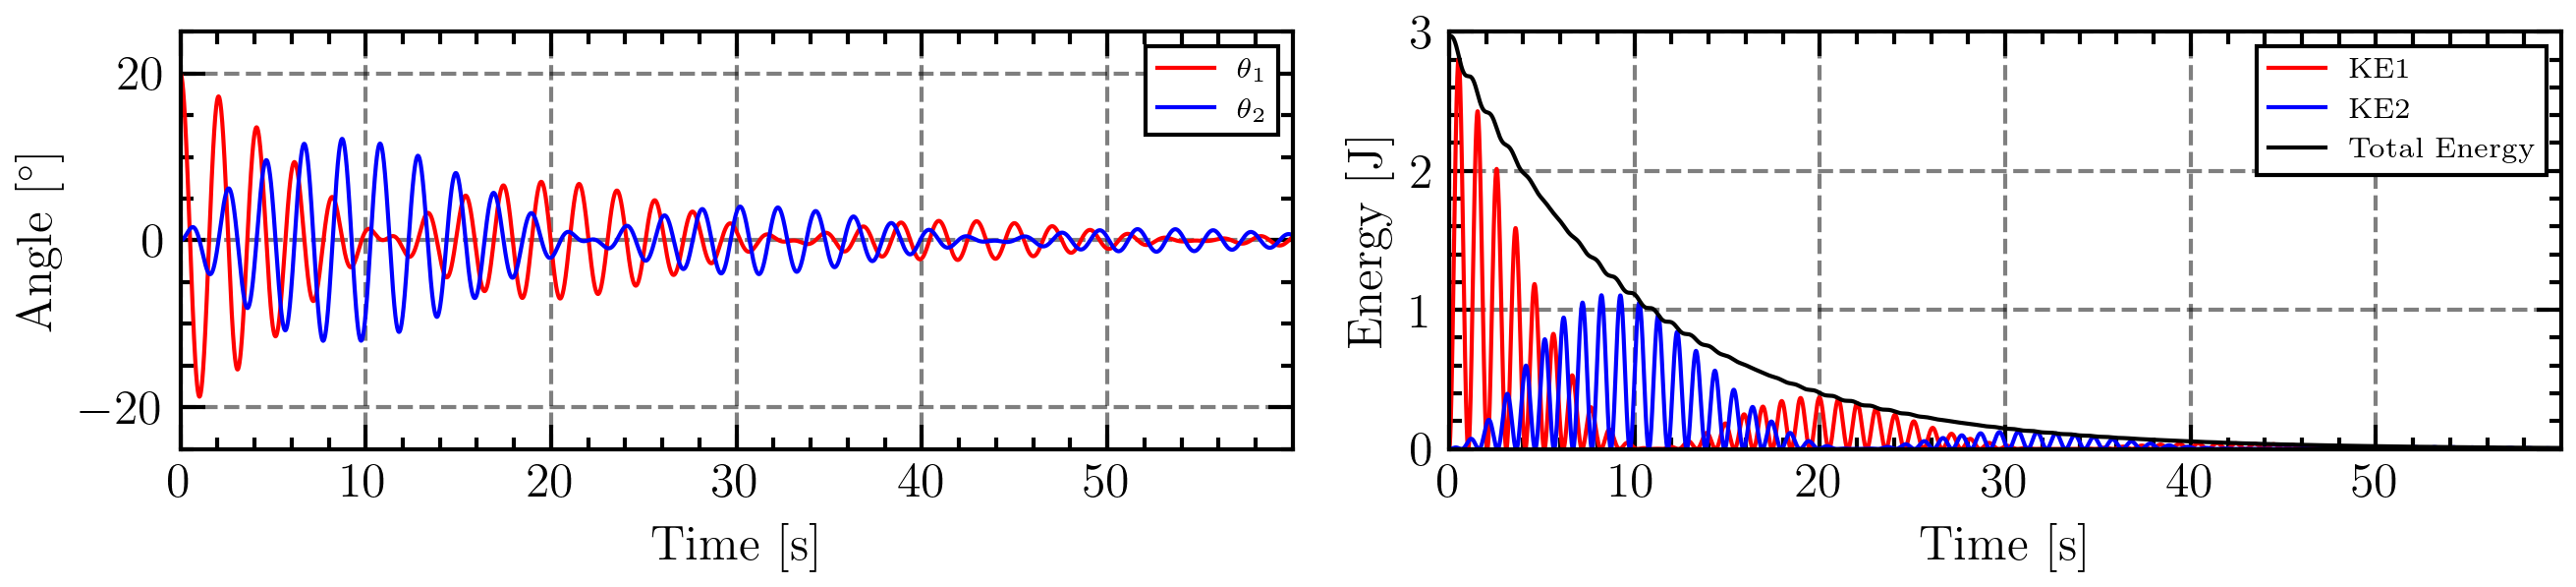

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 1.14         # pendulum length (m)
g = 9.80665      # gravity (m/s^2)
k = 18.5         # spring constant (N/m)
s = 0.5          # distance from pivot where spring is attached (m)
d = 0.25          # distance between pivots (m)
m = 4.03          # mass (kg)
I = m * L**2     # moment of inertia
beta = 0.1       # damping coefficient
dt = 0.01
tmax = 60
t = np.arange(0, tmax, dt)

# Verlet integrator
def spring_torque(theta1, theta2):
    r1 = np.array([-d/2 + s*np.sin(theta1), -s*np.cos(theta1)])
    r2 = np.array([ d/2 + s*np.sin(theta2), -s*np.cos(theta2)])
    dr = r2 - r1
    ell = np.linalg.norm(dr)
    dl = ell - d
    if ell == 0:
        return 0.0, 0.0
    u = dr / ell
    F1 =  k * dl * u
    F2 = -k * dl * u
    arm1 = np.array([s*np.sin(theta1), -s*np.cos(theta1)])
    arm2 = np.array([s*np.sin(theta2), -s*np.cos(theta2)])
    tau1 = arm1[0]*F1[1] - arm1[1]*F1[0]
    tau2 = arm2[0]*F2[1] - arm2[1]*F2[0]
    return tau1, tau2

def acc(t, theta1, omega1, theta2, omega2):
    tau1, tau2 = spring_torque(theta1, theta2)
    a1 = -(g/L)*np.sin(theta1) + tau1/I - beta*omega1
    a2 = -(g/L)*np.sin(theta2) + tau2/I - beta*omega2
    return a1, a2

def verlet_coupled(t, acc_func, theta1_0, omega1_0, theta2_0, omega2_0):
    n = len(t)
    th1, w1 = np.zeros(n), np.zeros(n)
    th2, w2 = np.zeros(n), np.zeros(n)
    a1, a2 = np.zeros(n), np.zeros(n)
    dt = t[1]-t[0]

    th1[0], th2[0] = theta1_0, theta2_0
    w1[0], w2[0] = omega1_0, omega2_0
    a1[0], a2[0] = acc_func(t[0], th1[0], w1[0], th2[0], w2[0])

    for i in range(n-1):
        th1[i+1] = th1[i] + w1[i]*dt + 0.5*a1[i]*dt**2
        th2[i+1] = th2[i] + w2[i]*dt + 0.5*a2[i]*dt**2
        a1_new, a2_new = acc_func(t[i+1], th1[i+1], w1[i], th2[i+1], w2[i])
        w1[i+1] = w1[i] + 0.5*(a1[i] + a1_new)*dt
        w2[i+1] = w2[i] + 0.5*(a2[i] + a2_new)*dt
        a1[i+1], a2[i+1] = a1_new, a2_new
    return th1, w1, th2, w2

# Energy computation
def compute_energy(theta1, omega1, theta2, omega2):
    # Gravitational potential
    U1 = m * g * L * (1 - np.cos(theta1))
    U2 = m * g * L * (1 - np.cos(theta2))
    # Kinetic energy (rotational)
    K1 = 0.5 * I * omega1**2
    K2 = 0.5 * I * omega2**2
    # Spring potential
    spring_energy = np.zeros_like(theta1)
    for i in range(len(theta1)):
        r1 = np.array([-d/2 + s*np.sin(theta1[i]), -s*np.cos(theta1[i])])
        r2 = np.array([ d/2 + s*np.sin(theta2[i]), -s*np.cos(theta2[i])])
        ell = np.linalg.norm(r2 - r1)
        dl = ell - d
        spring_energy[i] = 0.5 * k * dl**2
    total = K1 + K2 + U1 + U2 + spring_energy
    return K1, K2, total

# Simulation states
states = ['in phase', 'out of phase', 'one stationary']

for state in states:
    if state == 'in phase':
        theta1_0 = np.deg2rad(20)
        theta2_0 = np.deg2rad(20)
    elif state == 'out of phase':
        theta1_0 = np.deg2rad(20)
        theta2_0 = np.deg2rad(-20)
    elif state == 'one stationary':
        theta1_0 = np.deg2rad(20)
        theta2_0 = np.deg2rad(0)

    theta1, omega1, theta2, omega2 = verlet_coupled(t, acc, theta1_0, 0.0, theta2_0, 0.0)
    K1, K2, totalE = compute_energy(theta1, omega1, theta2, omega2)

    # Plot with subplots
    fig, axes = plt.subplots(1, 2, figsize=(6*1.5, 1.5*1.5),dpi=300)
    print(rf'\textbf{{Coupled Damped Pendula — {state}}}')

    # Left plot: Angles
    axes[0].plot(t, np.rad2deg(theta1), 'r-', label=r'$\theta_1$',lw=1)
    axes[0].plot(t, np.rad2deg(theta2), 'b-', label=r'$\theta_2$',lw=1)
    axes[0].set_xlabel('Time [s]')
    axes[0].set_ylabel(r'Angle [$^\circ$]')
    axes[0].legend(fancybox=False, edgecolor='k',fontsize=7)
    axes[0].set_ylim(-25, 25)
    axes[0].set_xlim(t.min(), t.max())

    # Right plot: Energies
    axes[1].plot(t, K1, 'r-', label='KE1',lw=1)
    axes[1].plot(t, K2, 'b-', label='KE2',lw=1)
    axes[1].plot(t, totalE, 'k-', label='Total Energy',lw=1)
    axes[1].set_xlabel('Time [s]')
    axes[1].set_ylabel('Energy [J]')
    axes[1].set_xlim(t.min(), t.max())
    axes[1].set_ylim(0,((totalE.max() // 0.25) + 1) * 0.25)
    axes[1].legend(fancybox=False, edgecolor='k',fontsize=7)

    plt.tight_layout()
    plt.show()
